In [1]:
import pandas as pd

D:\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('D:/Data_analysis/coffee_shop_analysis/coffee-shop-sales-revenue.csv', sep='|')

In [4]:
df.shape

(149116, 11)

In [5]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [6]:
df.tail(10)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
149106,149447,2023-06-30,19:56:45,1,8,Hell's Kitchen,33,3.50,Coffee,Gourmet brewed coffee,Ethiopia Lg
149107,149448,2023-06-30,19:57:49,2,3,Astoria,54,2.50,Tea,Brewed Chai tea,Morning Sunrise Chai Rg
149108,149449,2023-06-30,19:57:49,1,3,Astoria,70,3.25,Bakery,Scone,Cranberry Scone
149109,149450,2023-06-30,20:08:38,2,8,Hell's Kitchen,55,4.00,Tea,Brewed Chai tea,Morning Sunrise Chai Lg
149110,149451,2023-06-30,20:16:31,2,5,Lower Manhattan,42,2.50,Tea,Brewed herbal tea,Lemon Grass Rg
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino
149115,149456,2023-06-30,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup


In [7]:
df.shape

(149116, 11)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 22.3 MB


In [9]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='str')

In [10]:
df["store_location"].value_counts()

store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64

In [11]:
df["product_category"].value_counts()

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
#Lower Manhattan (The "Wall Street" Vibe) -- Financial District, Serious business professionals, stockbrokers, and tourists visiting the 9/11 Memorial.
#Hell's Kitchen(The "Theater & Foodie" Vibe) -- Actors, tourists, and locals(right next Theater District & Times Square)
#. Astoria (The "Residential Hub" Vibe) -- Families, young professionals, Greek Communities, feels more like "neighborhood" than a "business center."
df["store_id"].value_counts()

store_id
8    50735
3    50599
5    47782
Name: count, dtype: int64

In [14]:
df["revenue"] = df['transaction_qty'] * df['unit_price']

In [15]:
df.groupby(["store_id","store_location"]).size().reset_index(name="transaction_count")

,store_id,store_location,transaction_count
0,3,Astoria,50599
1,5,Lower Manhattan,47782
2,8,Hell's Kitchen,50735


In [16]:
df["product_detail"].value_counts()

product_detail
Chocolate Croissant             3076
Earl Grey Rg                    3053
Dark chocolate Lg               3029
Morning Sunrise Chai Rg         3026
Columbian Medium Roast Rg       3013
                                ... 
Jamacian Coffee River            146
Earl Grey                        142
Guatemalan Sustainably Grown     134
Spicy Eye Opener Chai            122
Dark chocolate                   118
Name: count, Length: 80, dtype: int64

In [17]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
revenue             0
dtype: int64

In [18]:
total_sales =  df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)

In [19]:
total_sales

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64

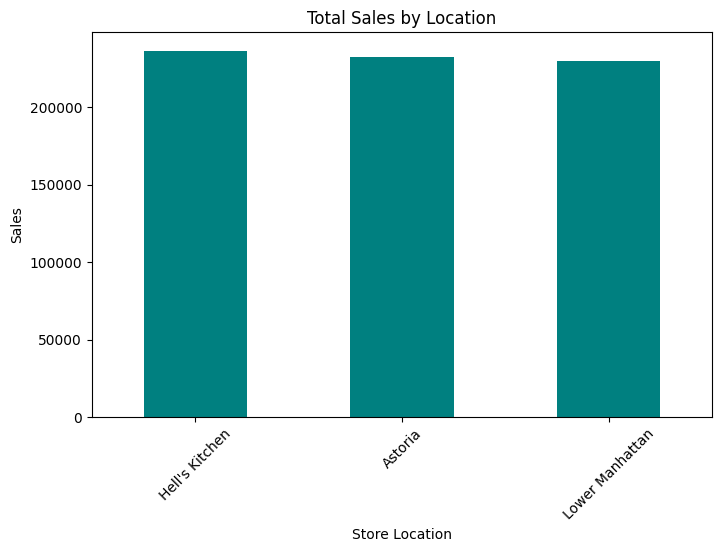

In [20]:
plt.figure(figsize=(8,5))
total_sales.plot(kind = 'bar', color = 'teal')

plt.title("Total Sales by Location")
plt.xlabel("Store Location")
plt.ylabel("Sales")
plt.xticks(rotation = 45)
plt.savefig('D:/Data_analysis/coffee_shop_analysis/total_sales.png')

In [21]:
df['transaction_date'].min()

'2023-01-01'

In [22]:
df['transaction_date'].max()

'2023-06-30'

In [23]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [24]:
#filtering in pandas = [] -> yes , () -> no...cause ur looking inside the box
df_filtered = df[df["store_location"] == "Hell's Kitchen"]

In [25]:
daily_sales_kitchen = df_filtered.groupby("transaction_date")["revenue"].sum()

In [26]:
print(daily_sales_kitchen)

transaction_date
2023-01-01     851.45
2023-01-02     828.80
2023-01-03     906.25
2023-01-04     781.65
2023-01-05     714.90
               ...   
2023-06-26    1746.10
2023-06-27    1676.70
2023-06-28    1445.85
2023-06-29    1298.55
2023-06-30    1904.93
Name: revenue, Length: 181, dtype: float64


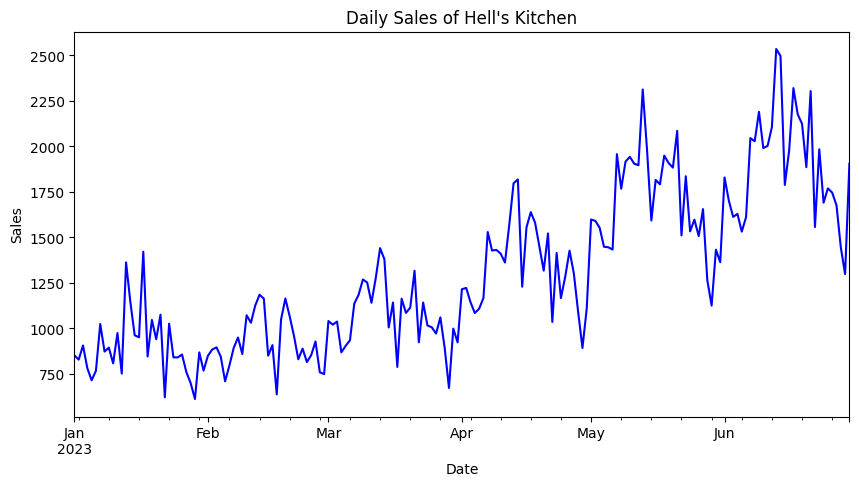

<Figure size 640x480 with 0 Axes>

In [27]:
daily_sales_kitchen.plot(kind = "line", color = "blue", figsize = (10, 5))
plt.title("Daily Sales of Hell's Kitchen")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/daily_sales_hells.png')

In [28]:
df_filtered_1 = df[df["store_location"] == "Astoria"]

In [29]:
daily_sales_astoria = df_filtered_1.groupby("transaction_date")["revenue"].sum()

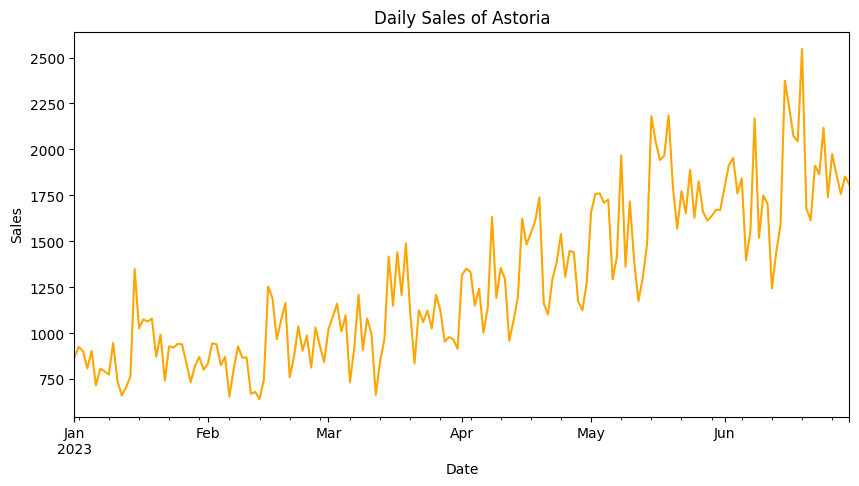

<Figure size 640x480 with 0 Axes>

In [30]:
daily_sales_astoria.plot(kind = "line", color = "orange", figsize = (10, 5))
plt.title("Daily Sales of Astoria")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/daily_sales_astoria.png')

In [31]:
df_filtered_2 = df[df["store_location"] == "Lower Manhattan"]

In [32]:
daily_sales_manhattan = df_filtered_2.groupby("transaction_date")["revenue"].sum()

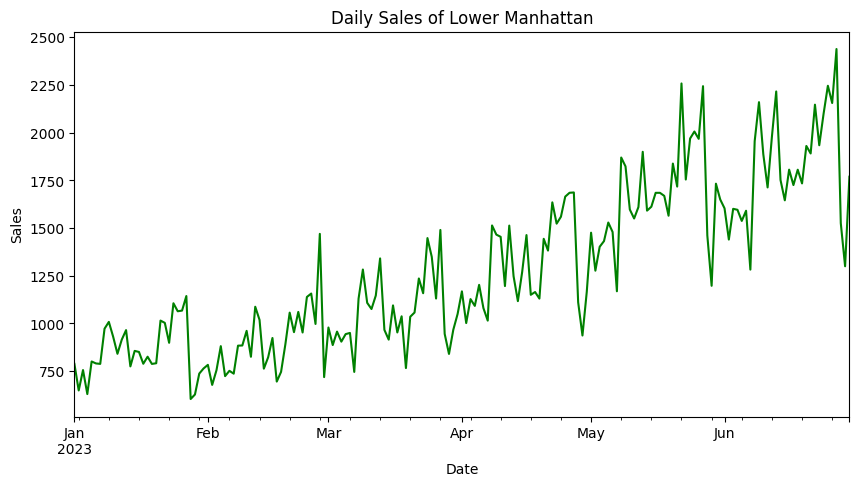

<Figure size 640x480 with 0 Axes>

In [33]:
daily_sales_manhattan.plot(kind = "line", color = "green", figsize = (10, 5))
plt.title("Daily Sales of Lower Manhattan")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/daily_sales_manhattan.png')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  str           
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
 11  revenue           149116 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(4), str(5)
memory usage: 22.1 MB


In [35]:
df['month'] = df['transaction_date'].dt.month

In [36]:
df['month']

0         1
1         1
2         1
3         1
4         1
         ..
149111    6
149112    6
149113    6
149114    6
149115    6
Name: month, Length: 149116, dtype: int32

In [37]:
monthly_sales = df.groupby(['month', 'store_location'])["revenue"].sum()

In [38]:
monthly_sales

month  store_location 
1      Astoria            27313.66
       Hell's Kitchen     27820.65
       Lower Manhattan    26543.43
2      Astoria            25105.34
       Hell's Kitchen     25719.80
       Lower Manhattan    25320.05
3      Astoria            32835.43
       Hell's Kitchen     33110.57
       Lower Manhattan    32888.68
4      Astoria            39477.61
       Hell's Kitchen     40304.14
       Lower Manhattan    39159.33
5      Astoria            52428.76
       Hell's Kitchen     52598.93
       Lower Manhattan    51700.07
6      Astoria            55083.11
       Hell's Kitchen     56957.08
       Lower Manhattan    54445.69
Name: revenue, dtype: float64

In [39]:
monthly_sales = monthly_sales.unstack()

In [40]:
monthly_sales

store_location,Astoria,Hell's Kitchen,Lower Manhattan
month,,,
1,27313.66,27820.65,26543.43
2,25105.34,25719.80,25320.05
3,32835.43,33110.57,32888.68
4,39477.61,40304.14,39159.33
5,52428.76,52598.93,51700.07
6,55083.11,56957.08,54445.69


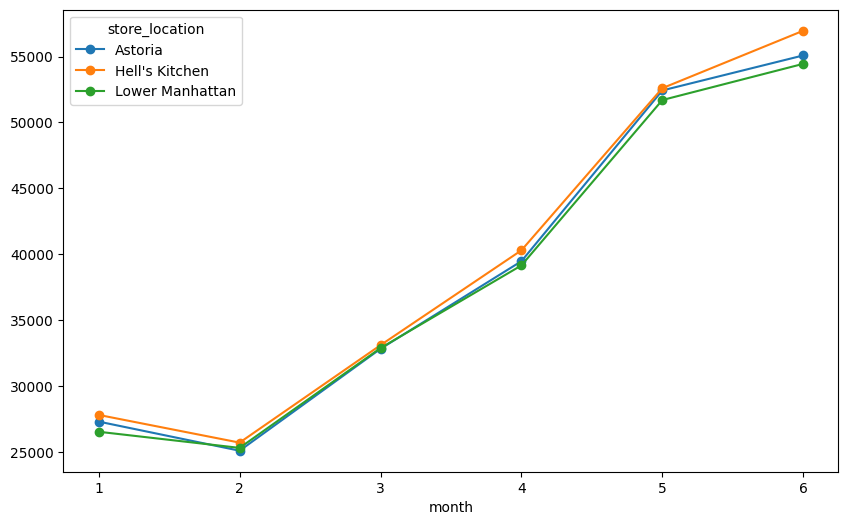

In [41]:
monthly_sales.plot(kind='line', marker='o', figsize=(10, 6))
plt.savefig('D:/Data_analysis/coffee_shop_analysis/monthly_sales.png')

In [42]:
top_10_overall = df.groupby('product_type')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_10_overall)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: revenue, dtype: float64


In [43]:
# Group by both, sum the money, then pivot (unstack)
store_product_comparison = df.groupby(['product_detail', 'store_location'])['revenue'].sum().unstack()

# Sort by the total of all stores to keep it organized
store_product_comparison['Total'] = store_product_comparison.sum(axis=1)
store_product_comparison = store_product_comparison.sort_values('Total', ascending=False).head(10)

print(store_product_comparison)

store_location                Astoria  Hell's Kitchen  Lower Manhattan  \
product_detail                                                           
Sustainably Grown Organic Lg  7509.75         7329.25          6312.75   
Dark chocolate Lg             7897.50         6534.00          6574.50   
Latte Rg                      6358.00         6366.50          6387.75   
Cappuccino Lg                 6128.50         5512.25          6001.00   
Morning Sunrise Chai Lg       6308.00         5652.00          5424.00   
Latte                         5853.75         5625.00          5778.75   
Jamaican Coffee River Lg      5816.25         5055.00          5610.00   
Sustainably Grown Organic Rg  5632.50         5302.50          5298.75   
Cappuccino                    5283.75         5576.25          5137.50   
Brazilian Lg                  4956.00         5432.00          4721.50   

store_location                   Total  
product_detail                          
Sustainably Grown Organic Lg 

In [44]:
# Group by both, sum the money, then pivot (unstack)
store_product_comparison_1 = df.groupby(['product_category', 'store_location'])['revenue'].sum().unstack()

# Sort by the total of all stores to keep it organized
store_product_comparison_1['Total'] = store_product_comparison.sum(axis=1)
store_product_comparison_1 = store_product_comparison_1.sort_values('Total', ascending=False).head(10)

print(store_product_comparison_1)

store_location       Astoria  Hell's Kitchen  Lower Manhattan  Total
product_category                                                    
Bakery              26599.75        27386.95         28328.94    NaN
Branded              5457.00         1942.00          6208.00    NaN
Coffee              89744.30        91222.65         88985.50    NaN
Coffee beans        10219.20        18635.10         11230.95    NaN
Drinking Chocolate  26335.25        23586.25         22494.50    NaN
Flavours             1764.80         2876.80          3767.20    NaN
Loose Tea            3194.00         4461.35          3558.25    NaN
Packaged Chocolate   1089.71         1698.77          1619.16    NaN
Tea                 67839.90        64701.30         63864.75    NaN


In [45]:
# Group by both, sum the money, then pivot (unstack)
store_product_comparison_2 = df.groupby(['product_type', 'store_location'])['revenue'].sum().unstack()

# Sort by the total of all stores to keep it organized
store_product_comparison_2['Total'] = store_product_comparison_2.sum(axis=1)
store_product_comparison_2 = store_product_comparison_2.sort_values('Total', ascending=False).head(10)

print(store_product_comparison_2)

store_location          Astoria  Hell's Kitchen  Lower Manhattan     Total
product_type                                                              
Barista Espresso       27935.00        32420.20         31051.00  91406.20
Brewed Chai tea        27427.90        25645.30         24008.75  77081.95
Hot chocolate          26335.25        23586.25         22494.50  72416.00
Gourmet brewed coffee  23823.30        23010.10         23201.20  70034.60
Brewed Black tea       16141.00        15575.50         16215.50  47932.00
Brewed herbal tea      16282.00        15263.00         15994.50  47539.50
Premium brewed coffee  13946.30        11927.85         12907.00  38781.15
Organic brewed coffee  12623.20        13114.00         12009.30  37746.50
Scone                  11629.75        12575.70         12660.67  36866.12
Drip coffee            11416.50        10750.50          9817.00  31984.00


In [46]:
"""store_product_comparison.drop(columns= "Total").plot(kind='bar', figsize=(12, 6))
plt.title("Top 10 Products Sales Count: Store Comparison")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()"""

'store_product_comparison.drop(columns= "Total").plot(kind=\'bar\', figsize=(12, 6))\nplt.title("Top 10 Products Sales Count: Store Comparison")\nplt.ylabel("Revenue")\nplt.xticks(rotation=45)\nplt.show()'

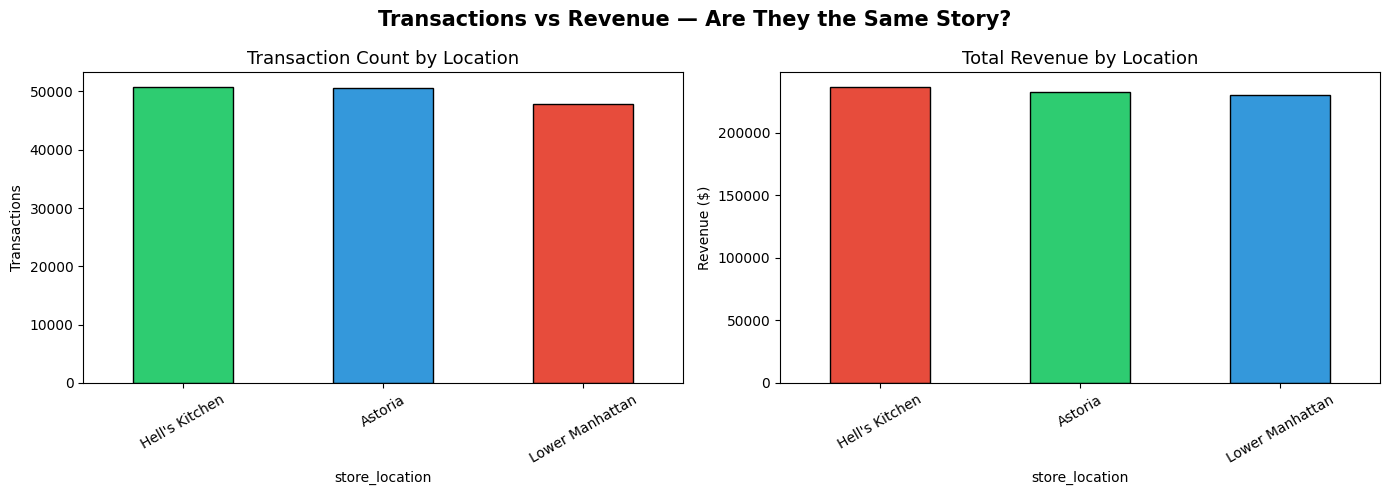

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions
df['store_location'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#3498db','#e74c3c'],
    edgecolor='black', width=0.5)
axes[0].set_title('Transaction Count by Location', fontsize=13)
axes[0].set_ylabel('Transactions')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Revenue
total_sales.plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71','#3498db'],
    edgecolor='black', width=0.5)
axes[1].set_title('Total Revenue by Location', fontsize=13)
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.suptitle('Transactions vs Revenue — Are They the Same Story?', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/transactions_vs_revenue.png', dpi=150)
plt.show()

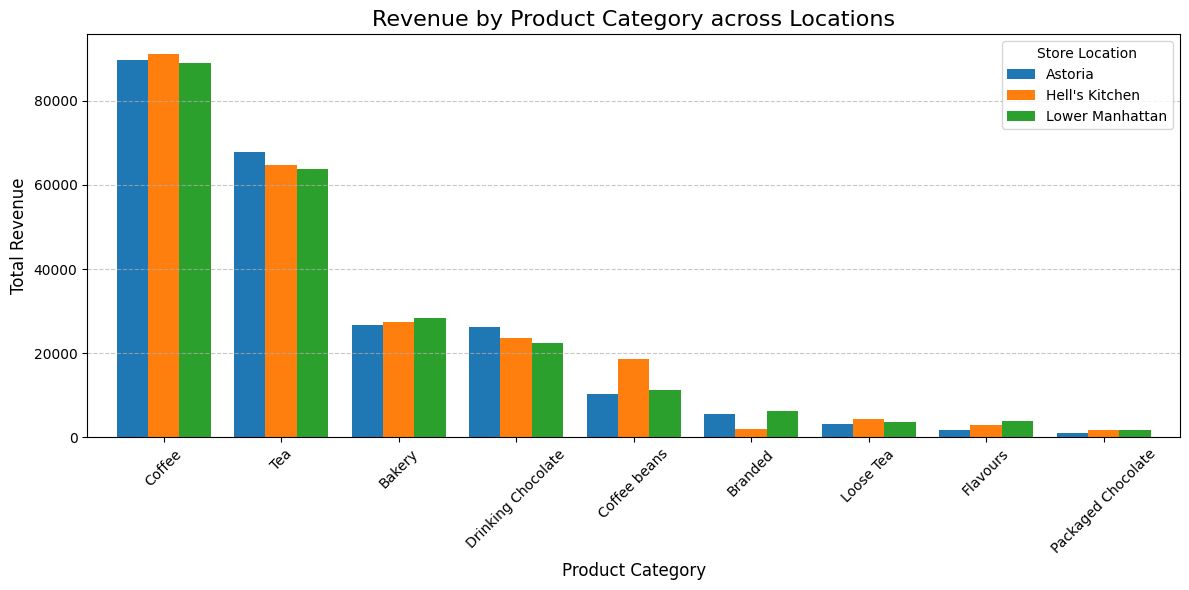

<Figure size 640x480 with 0 Axes>

In [48]:
#Group by Category and Location, then sum the revenue
cat_store_sales = df.groupby(['product_category', 'store_location'])['revenue'].sum().unstack()

#Sort the categories so the highest-selling ones are on the left
cat_store_sales['Total'] = cat_store_sales.sum(axis=1)
cat_store_sales = cat_store_sales.sort_values('Total', ascending=False).drop(columns='Total')

#Create the bar chart
cat_store_sales.plot(kind='bar', figsize=(12, 6), width=0.8)

#Add labels and clean up
plt.title("Revenue by Product Category across Locations", fontsize=16)
plt.ylabel("Total Revenue", fontsize=12)
plt.xlabel("Product Category", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Store Location")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

plt.savefig('D:/Data_analysis/coffee_shop_analysis/revenue_prod_cat.png')

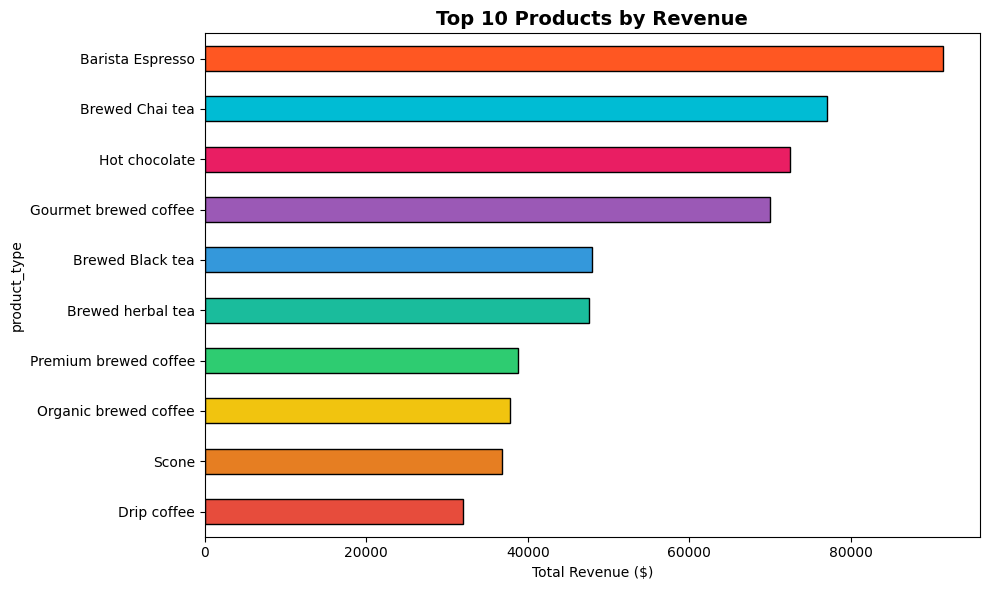

In [49]:
top_10_overall = df.groupby('product_type')['revenue'].sum()\
                   .sort_values(ascending=True).tail(10)

colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c',
          '#3498db','#9b59b6','#e91e63','#00bcd4','#ff5722']

plt.figure(figsize=(10, 6))
top_10_overall.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/top10_products.png', dpi=150)
plt.show()

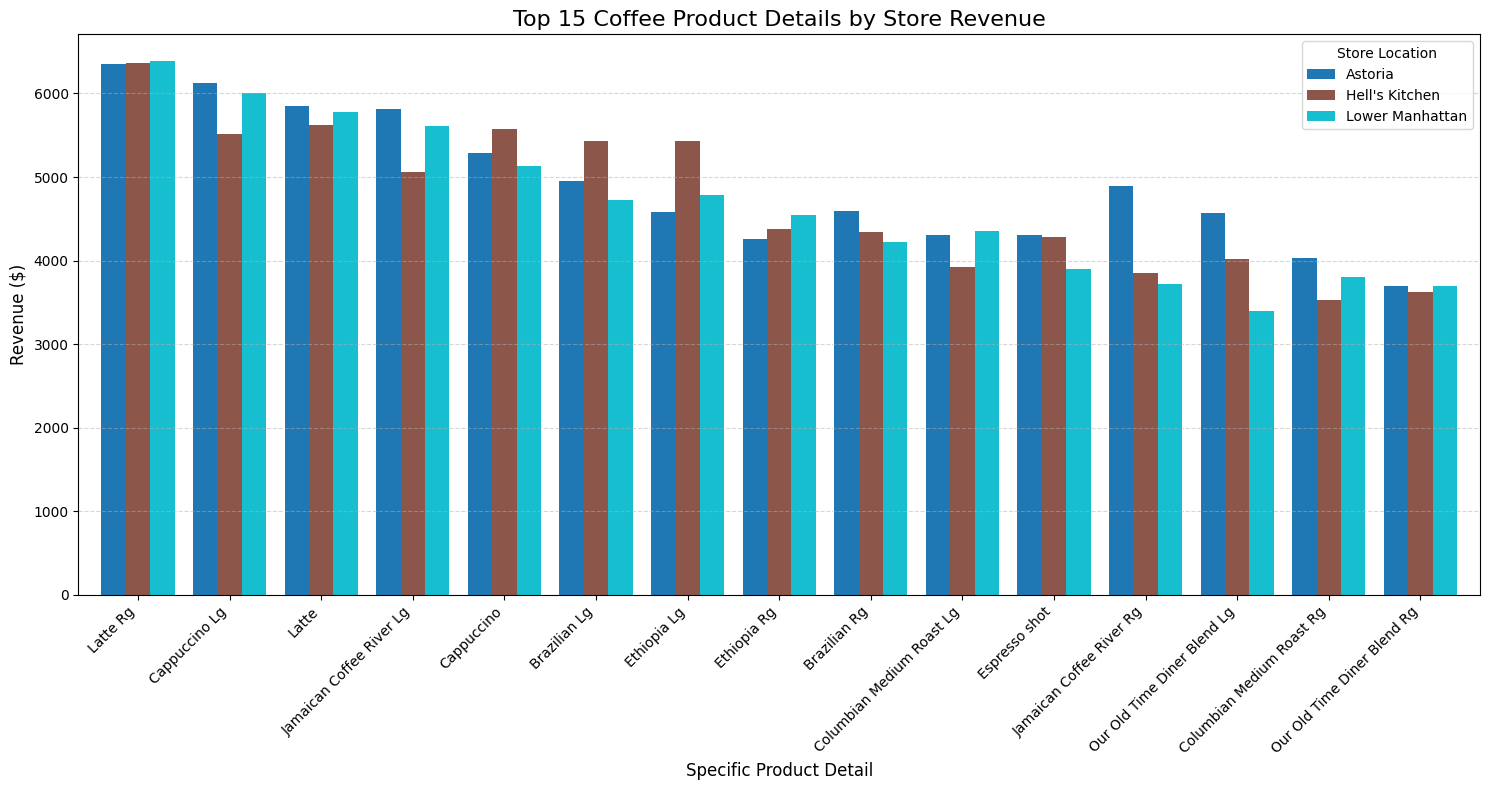

In [50]:
# 1. Filter for Coffee only
df_coffee = df[df['product_category'] == 'Coffee']

# 2. Group by Product Detail and Store
# We want to see the specific items making the most money
detail_comparison = df_coffee.groupby(['product_detail', 'store_location'])['revenue'].sum().unstack()

# 3. Calculate grand total to find the top sellers
detail_comparison['Grand_Total'] = detail_comparison.sum(axis=1)

# 4. Sort and take the Top 15 (otherwise the graph is unreadable)
top_details = detail_comparison.sort_values('Grand_Total', ascending=False).head(15)

# 5. Drop the Total column so it doesn't get plotted as a bar
top_details = top_details.drop(columns='Grand_Total')

# 6. Plotting
# Using 'tab10' for vibrant, distinct store colors
top_details.plot(kind='bar', figsize=(15, 8), width=0.8, colormap='tab10')

plt.title("Top 15 Coffee Product Details by Store Revenue", fontsize=16)
plt.ylabel("Revenue ($)", fontsize=12)
plt.xlabel("Specific Product Detail", fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns labels better
plt.legend(title="Store Location")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

category_counts = df["product_category"].value_counts().reset_index()
category_counts.columns = ["Product Category", "Transactions"]
category_counts["Transactions"] = category_counts["Transactions"].apply(lambda x: f"{x:,}")
category_counts.index = range(1, len(category_counts) + 1)

print(category_counts.to_string())

     Product Category Transactions
1              Coffee       58,416
2                 Tea       45,449
3              Bakery       22,796
4  Drinking Chocolate       11,468
5            Flavours        6,790
6        Coffee beans        1,753
7           Loose Tea        1,210
8             Branded          747
9  Packaged Chocolate          487


In [52]:
#pip install jinja2

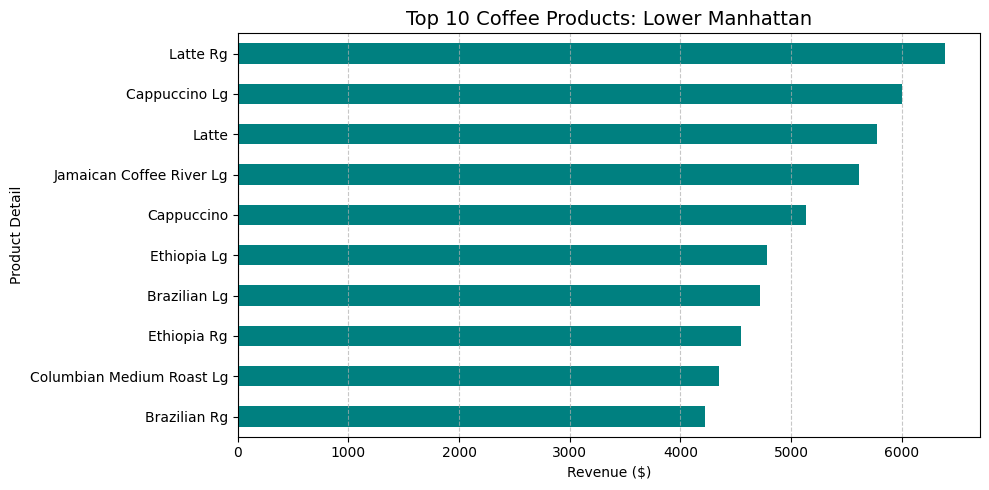

<Figure size 640x480 with 0 Axes>

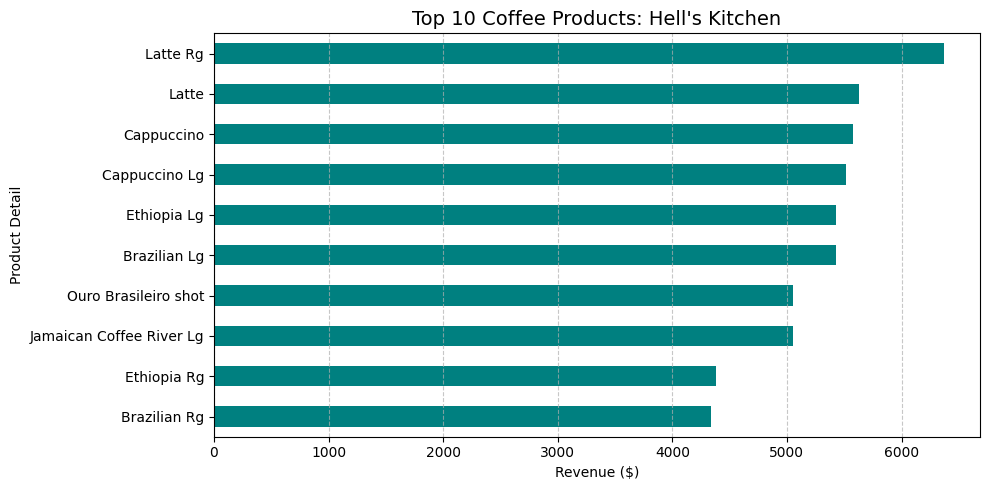

<Figure size 640x480 with 0 Axes>

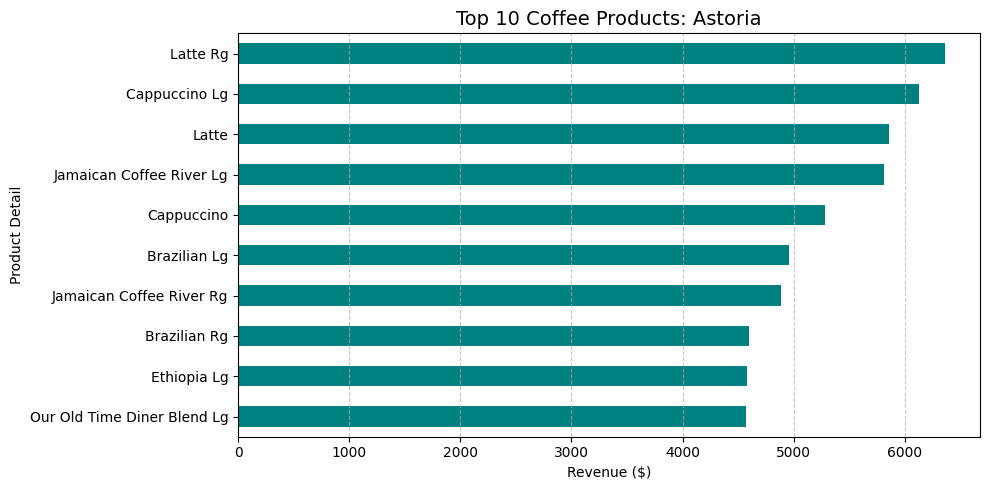

<Figure size 640x480 with 0 Axes>

In [53]:
# 1. Filter for Coffee
df_coffee = df[df['product_category'] == 'Coffee']

# 2. Get the list of unique store locations
stores = df_coffee['store_location'].unique()

# 3. Loop through each store to create a separate chart
for store in stores:
    # Filter data for just THIS store
    store_data = df_coffee[df_coffee['store_location'] == store]
    
    # Get Top 10 product details for this specific store
    top_items = store_data.groupby('product_detail')['revenue'].sum().sort_values(ascending=False).head(10)
    
    # Create the figure
    plt.figure(figsize=(10, 5))
    
    # Draw horizontal bars ('barh') - much easier to read long names!
    top_items.sort_values().plot(kind='barh', color='teal')
    
    plt.title(f"Top 10 Coffee Products: {store}", fontsize=14)
    plt.xlabel("Revenue ($)")
    plt.ylabel("Product Detail")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    plt.savefig('D:/Data_analysis/coffee_shop_analysis/top10.png')

Business questions 


In [55]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  str           
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
 11  revenue           149116 non-null  float64       
 12  month             149116 non-null  int32         
dtypes: datetime64[us](1), float64(2), int32(1), int64(4), str(5)
memory us

In [57]:
df.columns 

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'revenue', 'month'],
      dtype='str')

In [58]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price,revenue,month
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609,1.438276,5.342063,47.918607,3.382219,4.686367,3.988881
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000,0.800000,1.000000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000,3.000000,3.000000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000,3.750000,4.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000,6.000000,5.000000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000,360.000000,6.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723,4.227099,1.673091


In [59]:
#INTERQUARTILE RANGE
#Q1 = 3 , Q3 = 6 , IQR = Q3 - Q1 (6-3) = 3
#Lower Fence = Q1 - 1.5(IQR) = 3 - 1.5(3) = -1.5
#Upper Fence = Q3 + 1.5(IQR) = 6 + 1.5(3) = 10.5
#Outliers = outside this range ( - 1.5 , 10.5)

In [60]:
outliers = df[df["revenue"] > 10.5]

In [61]:
outliers.shape

(3273, 13)

In [62]:
outliers.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
3293,3323,2023-01-07,07:44:17,1,5,Lower Manhattan,6,21.00,Coffee beans,Gourmet Beans,Ethiopia,21.00,1
3296,3326,2023-01-07,07:45:15,1,5,Lower Manhattan,9,28.00,Coffee beans,Organic Beans,Organic Decaf Blend,28.00,1
3302,3332,2023-01-07,07:50:42,1,5,Lower Manhattan,9,28.00,Coffee beans,Organic Beans,Organic Decaf Blend,28.00,1
3408,3438,2023-01-07,09:05:19,1,5,Lower Manhattan,9,28.00,Coffee beans,Organic Beans,Organic Decaf Blend,28.00,1
3447,3477,2023-01-07,09:42:52,1,5,Lower Manhattan,7,19.75,Coffee beans,Premium Beans,Jamacian Coffee River,19.75,1


In [63]:
outliers["revenue"].max()

360.0

In [64]:
outliers["revenue"].min()

10.95

In [65]:
print(outliers['product_category'].value_counts())

product_category
Coffee beans          1619
Branded                747
Coffee                 378
Drinking Chocolate     182
Packaged Chocolate     148
Loose Tea              122
Tea                     77
Name: count, dtype: int64


In [66]:
df[df["revenue"] == 360]

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
9310,9340,2023-01-17,09:05:20,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,1
9365,9395,2023-01-17,09:55:47,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,1
68806,68976,2023-04-17,09:55:47,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,4
68981,69151,2023-04-17,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,4
97979,98233,2023-05-17,09:05:20,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,5
98275,98529,2023-05-17,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,5
133186,133523,2023-06-17,09:55:47,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,6
133337,133674,2023-06-17,10:41:11,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,6
133407,133744,2023-06-17,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,6
148702,149043,2023-06-30,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0,6


In [67]:
df[(df["revenue"] > 10.5) & (df["product_category"] == "Coffee")]

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
9366,9396,2023-01-17,09:58:43,3,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg,12.75,1
9851,9881,2023-01-18,09:14:24,3,5,Lower Manhattan,41,4.25,Coffee,Barista Espresso,Cappuccino Lg,12.75,1
9874,9904,2023-01-18,09:32:57,3,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg,12.75,1
11183,11213,2023-01-20,10:52:58,3,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte,11.25,1
11352,11382,2023-01-20,17:37:08,3,5,Lower Manhattan,36,3.75,Coffee,Premium brewed coffee,Jamaican Coffee River Lg,11.25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145759,146096,2023-06-27,17:19:02,3,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte,11.25,6
148481,148822,2023-06-30,09:54:07,3,5,Lower Manhattan,40,3.75,Coffee,Barista Espresso,Cappuccino,11.25,6
148723,149064,2023-06-30,11:31:21,3,5,Lower Manhattan,40,3.75,Coffee,Barista Espresso,Cappuccino,11.25,6
148856,149197,2023-06-30,14:22:01,3,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte,11.25,6


In [68]:
df[(df["revenue"] > 10.5) & (df["product_category"] == "Tea")]

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
11163,11193,2023-01-20,10:37:46,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,1
11319,11349,2023-01-20,16:34:24,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,1
11445,11475,2023-01-21,07:21:46,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,1
11533,11563,2023-01-21,08:30:04,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,1
13150,13180,2023-01-24,07:05:57,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142813,143150,2023-06-25,10:30:57,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,6
143157,143494,2023-06-25,15:04:48,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,6
144752,145089,2023-06-27,07:59:19,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,6
144816,145153,2023-06-27,08:20:34,3,5,Lower Manhattan,55,4.0,Tea,Brewed Chai tea,Morning Sunrise Chai Lg,12.0,6


In [69]:
#did not remove any outliers
#I identified 3,273 transactions above the IQR upper fence. 
#I investigated each product category and found all were valid — either high unit price products like premium coffee beans or bulk group orders. 
#I made the decision to keep all data and segment by product category for analysis

In [70]:
df["product_category"].value_counts()

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

In [71]:
Flavours = df[df["product_category"] == "Flavours"]

In [72]:
Flavours.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
3254,3284,2023-01-07,06:27:23,2,5,Lower Manhattan,64,0.8,Flavours,Regular syrup,Hazelnut syrup,1.6,1
3291,3321,2023-01-07,07:44:17,1,5,Lower Manhattan,63,0.8,Flavours,Regular syrup,Carmel syrup,0.8,1
3318,3348,2023-01-07,08:09:37,1,8,Hell's Kitchen,65,0.8,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,0.8,1
3325,3355,2023-01-07,08:18:07,1,5,Lower Manhattan,65,0.8,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,0.8,1
3331,3361,2023-01-07,08:20:30,1,5,Lower Manhattan,64,0.8,Flavours,Regular syrup,Hazelnut syrup,0.8,1


In [73]:
Bakery = df[df["product_category"] == "Bakery"]

In [74]:
Bakery.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
5,6,2023-01-01,07:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone,3.00,1
16,17,2023-01-01,07:59:58,1,5,Lower Manhattan,79,3.75,Bakery,Scone,Jumbo Savory Scone,3.75,1
22,23,2023-01-01,08:24:26,1,5,Lower Manhattan,69,3.25,Bakery,Biscotti,Hazelnut Biscotti,3.25,1
26,27,2023-01-01,08:33:08,1,5,Lower Manhattan,76,3.50,Bakery,Biscotti,Chocolate Chip Biscotti,3.50,1
28,29,2023-01-01,08:35:03,1,5,Lower Manhattan,71,3.75,Bakery,Pastry,Chocolate Croissant,3.75,1


In [75]:
Bakery["product_type"].value_counts()

product_type
Scone       10173
Pastry       6912
Biscotti     5711
Name: count, dtype: int64

In [76]:
Branded = df[df["product_category"] == "Branded"]

In [77]:
Branded["product_type"].value_counts()

product_type
Housewares    526
Clothing      221
Name: count, dtype: int64

In [78]:
Branded.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
4033,4063,2023-01-08,10:22:32,1,5,Lower Manhattan,83,14.0,Branded,Housewares,I Need My Bean! Latte cup,14.0,1
4359,4389,2023-01-08,19:54:56,1,3,Astoria,83,14.0,Branded,Housewares,I Need My Bean! Latte cup,14.0,1
4466,4496,2023-01-09,08:02:30,1,5,Lower Manhattan,83,14.0,Branded,Housewares,I Need My Bean! Latte cup,14.0,1
4594,4624,2023-01-09,09:40:56,1,5,Lower Manhattan,83,14.0,Branded,Housewares,I Need My Bean! Latte cup,14.0,1
4598,4628,2023-01-09,09:42:16,1,5,Lower Manhattan,81,28.0,Branded,Clothing,I Need My Bean! T-shirt,28.0,1


In [79]:
loose_tea = df[df["product_category"] == "Loose Tea"]

In [80]:
loose_tea

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
3263,3293,2023-01-07,07:07:56,1,5,Lower Manhattan,12,8.95,Loose Tea,Herbal tea,Peppermint,8.95,1
3481,3511,2023-01-07,10:10:10,1,8,Hell's Kitchen,17,9.50,Loose Tea,Chai tea,Morning Sunrise Chai,9.50,1
3880,3910,2023-01-08,08:13:57,1,3,Astoria,15,9.25,Loose Tea,Green tea,Serenity Green Tea,9.25,1
3896,3926,2023-01-08,08:26:31,1,8,Hell's Kitchen,16,8.95,Loose Tea,Chai tea,Traditional Blend Chai,8.95,1
3982,4012,2023-01-08,09:40:37,1,8,Hell's Kitchen,17,9.50,Loose Tea,Chai tea,Morning Sunrise Chai,9.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148647,148988,2023-06-30,10:47:11,1,3,Astoria,14,8.95,Loose Tea,Black tea,Earl Grey,8.95,6
148659,149000,2023-06-30,10:53:26,1,3,Astoria,18,10.95,Loose Tea,Chai tea,Spicy Eye Opener Chai,10.95,6
148663,149004,2023-06-30,10:54:04,1,5,Lower Manhattan,17,9.50,Loose Tea,Chai tea,Morning Sunrise Chai,9.50,6
148816,149157,2023-06-30,13:45:06,1,5,Lower Manhattan,16,8.95,Loose Tea,Chai tea,Traditional Blend Chai,8.95,6


In [81]:
loose_tea["product_type"].value_counts()

product_type
Chai tea      443
Herbal tea    305
Black tea     303
Green tea     159
Name: count, dtype: int64

In [82]:
chocolate = df[df["product_category"] == "Drinking Chocolate"]

In [83]:
chocolate.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,1
9,10,2023-01-01,07:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg,7.00,1
18,19,2023-01-01,08:00:39,2,8,Hell's Kitchen,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,1
19,20,2023-01-01,08:11:45,1,8,Hell's Kitchen,61,4.75,Drinking Chocolate,Hot chocolate,Sustainably Grown Organic Lg,4.75,1
41,42,2023-01-01,09:10:30,2,5,Lower Manhattan,60,3.75,Drinking Chocolate,Hot chocolate,Sustainably Grown Organic Rg,7.50,1


In [84]:
chocolate["product_type"].value_counts()

product_type
Hot chocolate    11468
Name: count, dtype: int64

In [85]:
packaged_chocolate = df[df["product_category"] == "Packaged Chocolate"]

In [86]:
packaged_chocolate.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month
3440,3470,2023-01-07,09:31:57,1,5,Lower Manhattan,19,6.40,Packaged Chocolate,Drinking Chocolate,Dark chocolate,6.40,1
3630,3660,2023-01-07,12:26:42,1,8,Hell's Kitchen,19,6.40,Packaged Chocolate,Drinking Chocolate,Dark chocolate,6.40,1
4022,4052,2023-01-08,10:12:05,1,8,Hell's Kitchen,20,7.60,Packaged Chocolate,Organic Chocolate,Sustainably Grown Organic,7.60,1
4257,4287,2023-01-08,16:12:35,1,8,Hell's Kitchen,21,13.33,Packaged Chocolate,Drinking Chocolate,Chili Mayan,13.33,1
4431,4461,2023-01-09,07:38:22,1,3,Astoria,20,7.60,Packaged Chocolate,Organic Chocolate,Sustainably Grown Organic,7.60,1


In [87]:
packaged_chocolate["product_type"].value_counts()

product_type
Drinking Chocolate    266
Organic Chocolate     221
Name: count, dtype: int64

In [88]:
#df[df["transaction_id"].isin(df[df["product_category"] == "Flavours"]["transaction_id"])].sort_values("transaction_id").head(10)

In [89]:
df_drinks  = df[df["product_category"].isin(["Coffee", "Tea", "Drinking Chocolate"])]

In [90]:
df_drinks.shape

(115333, 13)

In [91]:
#df_food  = df[df["product_category"].isin(["Bakery"])]

In [92]:
#df_food.shape

In [93]:
#df_extras = df[df["product_category"].isin(["Flavours"])]

In [94]:
df_packaged  = df[df["product_category"].isin(["Coffee beans", "Loose Tea", "Branded", "Packaged Chocolate"])]

In [95]:
df_drinks.shape[0] + Bakery.shape[0] + Flavours.shape[0] + df_packaged.shape[0]

149116

In [96]:
contingency_table = pd.crosstab(df['store_location'], df['product_category'])
print(contingency_table)

product_category  Bakery  Branded  Coffee  Coffee beans  Drinking Chocolate  \
store_location                                                                
Astoria             7289      279   20025           502                4300   
Hell's Kitchen      7617      119   20187           720                3763   
Lower Manhattan     7890      349   18204           531                3405   

product_category  Flavours  Loose Tea  Packaged Chocolate    Tea  
store_location                                                    
Astoria               1490        344                 110  16260  
Hell's Kitchen        2370        485                 197  15277  
Lower Manhattan       2930        381                 180  13912  


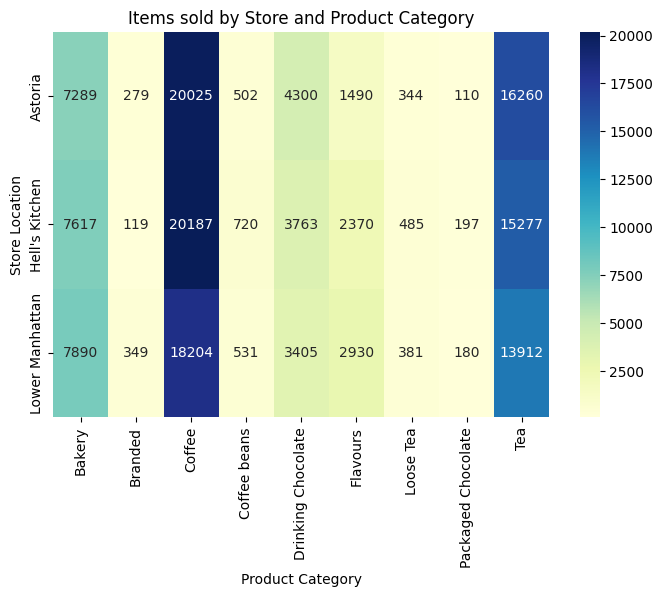

<Figure size 640x480 with 0 Axes>

In [97]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Items sold by Store and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Store Location")
plt.show()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/items_sold.png')

In [98]:
from scipy.stats import chi2_contingency

In [99]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

In [100]:
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

Chi-Square Statistic: 1009.8996
P-value: 0.0000
Degrees of Freedom: 16


In [101]:
"""# Group by store and category
store_category = df.groupby(['store_location', 'product_category'])['transaction_id'].count().reset_index()
store_category.columns = ['store_location', 'product_category', 'count']

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for store in store_category['store_location'].unique():
    data = store_category[store_category['store_location'] == store]
    ax.bar(data['product_category'], data['count'], label=store, alpha=0.7)

ax.set_title('Product Category Purchases by Store Location')
ax.set_xlabel('Product Category')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('category_by_store.png')
plt.show()"""

"# Group by store and category\nstore_category = df.groupby(['store_location', 'product_category'])['transaction_id'].count().reset_index()\nstore_category.columns = ['store_location', 'product_category', 'count']\n\n# Plot\nfig, ax = plt.subplots(figsize=(14, 6))\nfor store in store_category['store_location'].unique():\n    data = store_category[store_category['store_location'] == store]\n    ax.bar(data['product_category'], data['count'], label=store, alpha=0.7)\n\nax.set_title('Product Category Purchases by Store Location')\nax.set_xlabel('Product Category')\nax.set_ylabel('Number of Transactions')\nax.legend()\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.savefig('category_by_store.png')\nplt.show()"

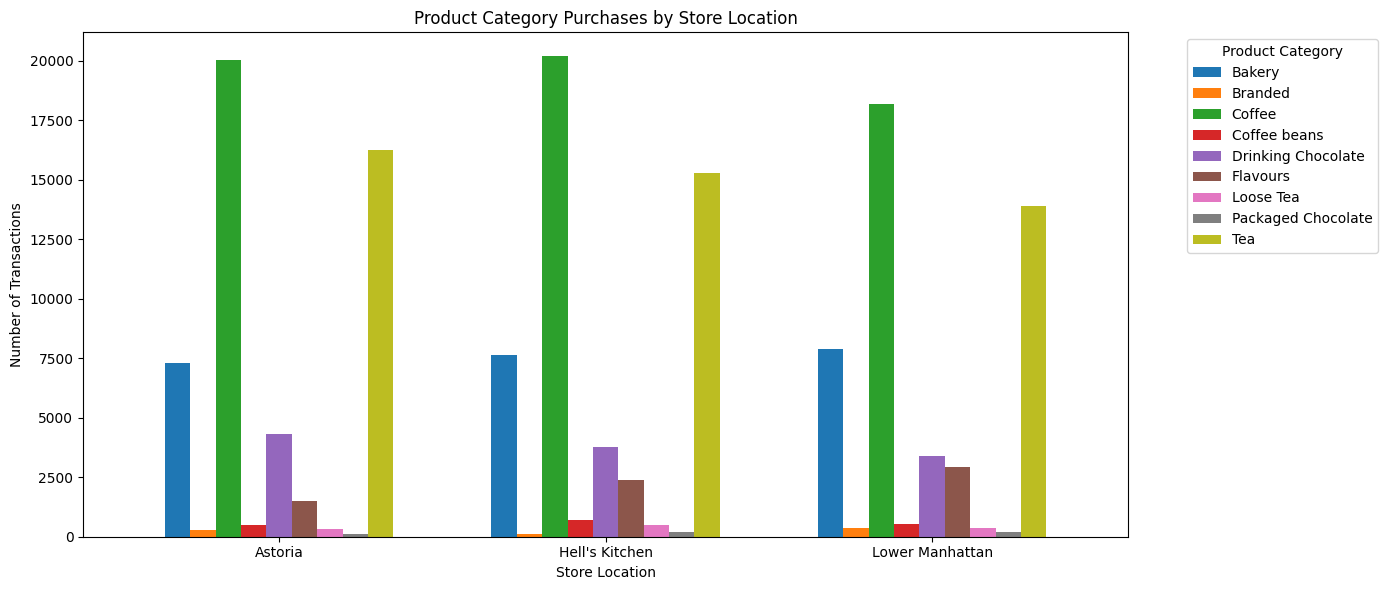

In [102]:
import numpy as np

store_category = df.groupby(['store_location', 'product_category'])['transaction_id'].count().unstack()

store_category.plot(kind='bar', figsize=(14, 6), width=0.7)

plt.title('Product Category Purchases by Store Location')
plt.xlabel('Store Location')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/cat_sold_store.png')
plt.show()

In [103]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')

In [104]:
df['hour'] = df['transaction_time'].dt.hour

In [105]:
df.tail()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month,hour
149111,149452,2023-06-30,1900-01-01 20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,6,20
149112,149453,2023-06-30,1900-01-01 20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,6,20
149113,149454,2023-06-30,1900-01-01 20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,6,20
149114,149455,2023-06-30,1900-01-01 20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,6,20
149115,149456,2023-06-30,1900-01-01 20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup,1.60,6,20


In [106]:
#Morning = 5 AM - 11 AM
#Afternoon = 12 PM - 5 PM
#Evening = 6 PM - 10 PM

In [107]:
def get_time_period(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 22:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour'].apply(get_time_period)

In [108]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month,hour,time_period
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,7,Morning
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,7,Morning
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,7,Morning
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,7,Morning
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,7,Morning


In [109]:
#print(df['transaction_qty'].describe())

In [110]:
#print(df['transaction_qty'].value_counts().sort_index())

In [111]:
# Step 2 — Count transactions per time period
transaction_counts = df.groupby('time_period')['transaction_id'].count()
print("Transaction counts by time period:")
print(transaction_counts)

Transaction counts by time period:
time_period
Afternoon    53172
Evening      14193
Morning      81751
Name: transaction_id, dtype: int64


In [112]:
total = transaction_counts.sum()
print(f"Total transactions: {total}")

Total transactions: 149116


In [113]:
store_time = df.groupby(['store_location', 'time_period'])['transaction_id'].count().unstack()
print(store_time)

time_period      Afternoon  Evening  Morning
store_location                              
Astoria              20637     7028    22934
Hell's Kitchen       15835     5538    29362
Lower Manhattan      16700     1627    29455


In [114]:
revenue_time = df.groupby(['store_location', 'time_period'])['revenue'].sum().unstack()

In [115]:
revenue_time

time_period,Afternoon,Evening,Morning
store_location,,,
Astoria,94406.44,32894.95,104942.52
Hell's Kitchen,71801.93,25265.94,139443.30
Lower Manhattan,78646.77,7507.63,143902.85


In [116]:
import matplotlib.ticker as mticker

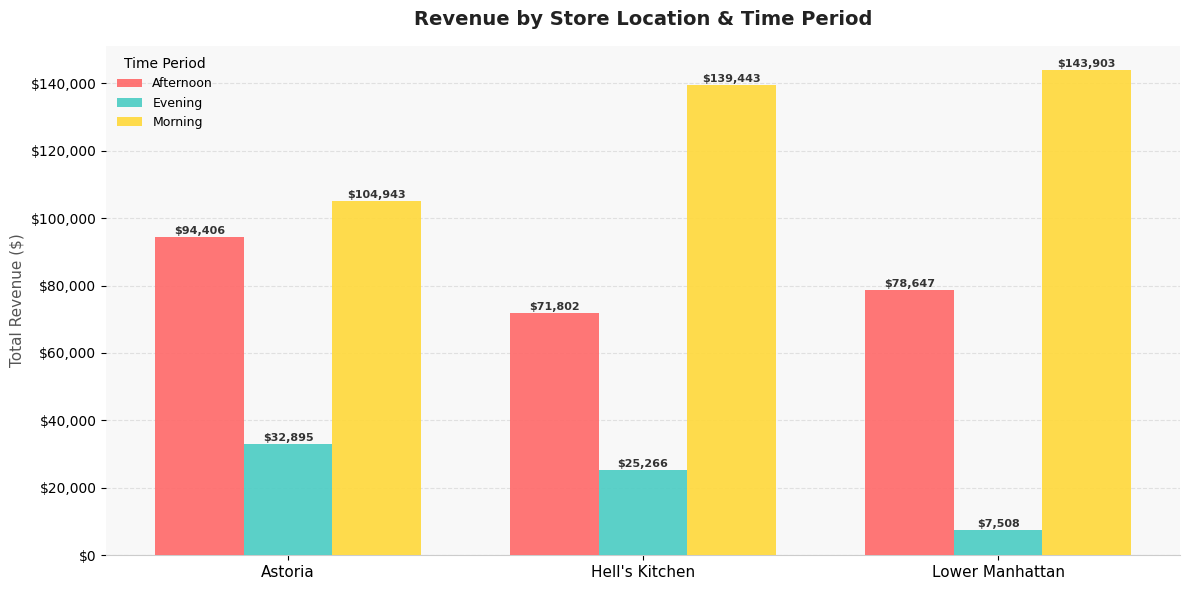

In [117]:
fig, ax = plt.subplots(figsize=(12, 6))

stores = revenue_time.index
periods = revenue_time.columns
x = np.arange(len(stores))
width = 0.25

# Vibrant modern palette
colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']

for i, period in enumerate(periods):
    bars = ax.bar(x + i * width, revenue_time[period],
                  width=width, label=period,
                  color=colors[i], edgecolor='none',
                  alpha=0.92, zorder=3)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                height + 300,
                f'${height:,.0f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold',
                color='#333333')

# Clean background
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('#FFFFFF')

# Gridlines behind bars
ax.yaxis.grid(True, color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Remove spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

# Labels
ax.set_xticks(x + width)
ax.set_xticklabels(stores, fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11, color='#555555')
ax.set_title('Revenue by Store Location & Time Period',
             fontsize=14, fontweight='bold', pad=15, color='#222222')

# Format y-axis
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))

ax.legend(title='Time Period', title_fontsize=10,
          fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/revenue_by_store_time.png', dpi=150, bbox_inches='tight')
plt.show()

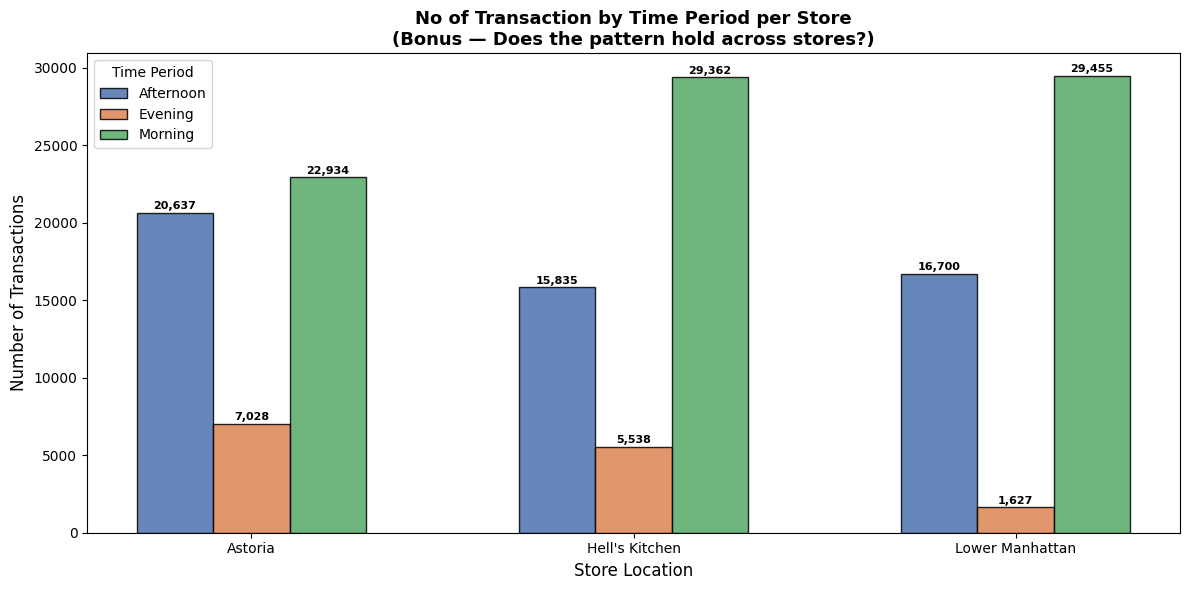

In [118]:
# Chart — Grouped Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(store_time.index))  # store locations
width = 0.2
colors = ['#4C72B0', '#DD8452', '#55A868', '#8B5CF6']

for i, period in enumerate(store_time.columns):
    bars = ax.bar(x + i * width, store_time[period], 
                  width=width, label=period, 
                  color=colors[i], edgecolor='black', alpha=0.85)
    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 100,
                f'{int(height):,}', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')

ax.set_xlabel('Store Location', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_title('No of Transaction by Time Period per Store\n(Bonus — Does the pattern hold across stores?)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(store_time.index)
ax.legend(title='Time Period')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/q1_bonus_store_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
# Step 3 — Chi-Square Goodness of Fit
# H0: Transactions are equally distributed across time periods
# H1: At least one time period is significantly different
from scipy.stats import chisquare

In [120]:
observed = transaction_counts.values  
expected = [total / len(observed)] * len(observed)

chi2, p = chisquare(f_obs=observed, f_exp=expected)

In [121]:
print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p:.6f}")


Chi-Square Statistic : 46274.0755
P-Value              : 0.000000


In [331]:
if p < 0.05:
    print("Reject H₀ — Transactions are NOT equally distributed across time periods!")
else:
    print("Fail to Reject H₀ — No significant difference in transaction counts across time periods.")


Reject H₀ — Transactions are NOT equally distributed across time periods!


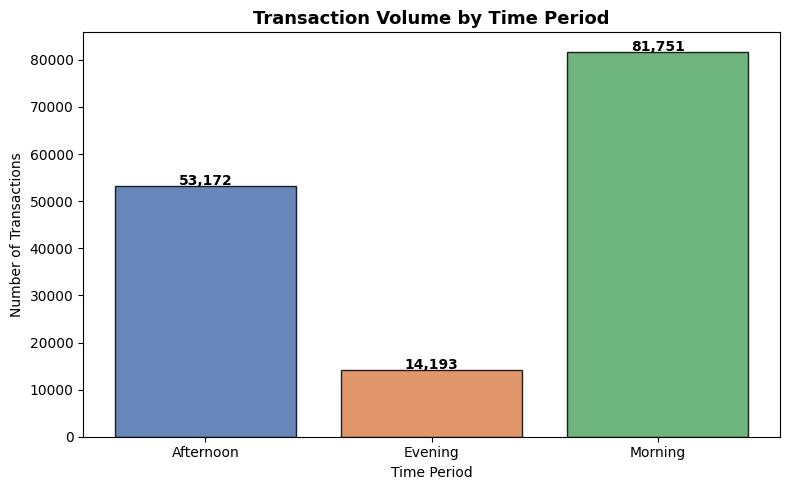

In [123]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#8B5CF6']
plt.figure(figsize=(8, 5))
plt.bar(transaction_counts.index, transaction_counts.values,
        color=colors[:len(transaction_counts)], edgecolor='black', alpha=0.85)
plt.title('Transaction Volume by Time Period', fontweight='bold', fontsize=13)
plt.xlabel('Time Period')
plt.ylabel('Number of Transactions')
for i, v in enumerate(transaction_counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/trans_vol_time', dpi=150, bbox_inches='tight')
plt.show()

In [124]:
# Step 1 — Create basket_id (same time + same store = same customer visit)
df['transaction_time_clean'] = pd.to_datetime(df['transaction_time']).dt.time

In [125]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month,hour,time_period,transaction_time_clean
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,7,Morning,07:06:11
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,7,Morning,07:08:56
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,7,Morning,07:14:04
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,7,Morning,07:20:24
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,7,Morning,07:22:41


In [126]:
df['basket_id'] = (df['transaction_date'].astype(str) + '_' + 
                   df['transaction_time_clean'].astype(str) + '_' + 
                   df['store_location'].astype(str))

In [127]:
df["basket_id"]

0         2023-01-01_07:06:11_Lower Manhattan
1         2023-01-01_07:08:56_Lower Manhattan
2         2023-01-01_07:14:04_Lower Manhattan
3         2023-01-01_07:20:24_Lower Manhattan
4         2023-01-01_07:22:41_Lower Manhattan
                         ...                 
149111     2023-06-30_20:18:41_Hell's Kitchen
149112     2023-06-30_20:25:10_Hell's Kitchen
149113     2023-06-30_20:31:34_Hell's Kitchen
149114     2023-06-30_20:57:19_Hell's Kitchen
149115     2023-06-30_20:57:19_Hell's Kitchen
Name: basket_id, Length: 149116, dtype: str

In [128]:
df.head(7)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month,hour,time_period,transaction_time_clean,basket_id
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,7,Morning,07:06:11,2023-01-01_07:06:11_Lower Manhattan
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,7,Morning,07:08:56,2023-01-01_07:08:56_Lower Manhattan
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,7,Morning,07:14:04,2023-01-01_07:14:04_Lower Manhattan
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,7,Morning,07:20:24,2023-01-01_07:20:24_Lower Manhattan
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,7,Morning,07:22:41,2023-01-01_07:22:41_Lower Manhattan
5,6,2023-01-01,1900-01-01 07:22:41,1,5,Lower Manhattan,77,3.0,Bakery,Scone,Oatmeal Scone,3.0,1,7,Morning,07:22:41,2023-01-01_07:22:41_Lower Manhattan
6,7,2023-01-01,1900-01-01 07:25:49,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,7,Morning,07:25:49,2023-01-01_07:25:49_Lower Manhattan


In [129]:
# Step 2 — Group by basket, flag coffee and bakery
basket_products = df.groupby('basket_id')['product_category'].apply(set).reset_index()

In [130]:
basket_products

,basket_id,product_category
0,2023-01-01_07:06:11_Lower Manhattan,{Coffee}
1,2023-01-01_07:08:56_Lower Manhattan,{Tea}
2,2023-01-01_07:14:04_Lower Manhattan,{Drinking Chocolate}
3,2023-01-01_07:20:24_Lower Manhattan,{Coffee}
4,2023-01-01_07:22:41_Lower Manhattan,"{Tea, Bakery}"
...,...,...
116785,2023-06-30_20:16:31_Lower Manhattan,{Tea}
116786,2023-06-30_20:18:41_Hell's Kitchen,{Tea}
116787,2023-06-30_20:25:10_Hell's Kitchen,{Tea}
116788,2023-06-30_20:31:34_Hell's Kitchen,{Tea}


In [131]:
basket_products['has_coffee'] = basket_products['product_category'].apply(lambda x: 'Coffee' in x)
basket_products['has_bakery'] = basket_products['product_category'].apply(lambda x: 'Bakery' in x)

In [132]:
#print(basket_products[['has_coffee', 'has_bakery']].head(5))
print("\nCoffee distribution:")
print(basket_products['has_coffee'].value_counts())
print("\nBakery distribution:")
print(basket_products['has_bakery'].value_counts())


Coffee distribution:
has_coffee
False    58619
True     58171
Name: count, dtype: int64

Bakery distribution:
has_bakery
False    94430
True     22360
Name: count, dtype: int64


In [133]:
# Step 3 — Contingency Table
contingency = pd.crosstab(basket_products['has_coffee'],
                           basket_products['has_bakery'])
print("\nContingency Table:")
print(contingency)


Contingency Table:
has_bakery  False  True 
has_coffee              
False       46852  11767
True        47578  10593


In [134]:
chi2, p, dof, expected = chi2_contingency(contingency)

In [135]:
print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p:.6f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Any expected cell < 5? {(expected < 5).any()}")


Chi-Square Statistic : 65.3840
P-Value              : 0.000000
Degrees of Freedom   : 1
Any expected cell < 5? False


In [136]:
if p < 0.05:
    print("Reject H₀ — Coffee and Bakery ARE bought together!")
else:
    print("Fail to Reject H₀ — No significant relationship.")

Reject H₀ — Coffee and Bakery ARE bought together!


In [137]:
# Step 5 — Cramér's V (strength of association)
n = contingency.values.sum()
v = np.sqrt(chi2 / (n * 1))   
print(f"\nCramér's V : {v:.4f}")

if v < 0.1:
    print("Very weak association")
elif v < 0.3:
    print("Weak association")
elif v < 0.5:
    print("Moderate association")
else:
    print("Strong association")


Cramér's V : 0.0237
Very weak association


In [138]:
# Step 6 — Lift (how much more likely bakery with coffee vs without)
p_coffee = basket_products['has_coffee'].mean()
p_bakery = basket_products['has_bakery'].mean()
p_both   = (basket_products['has_coffee'] & basket_products['has_bakery']).mean()
lift = p_both / (p_coffee * p_bakery)
print(f"\nLift : {lift:.4f}")
if lift > 1:
    print("Customers who buy coffee ARE more likely to also buy bakery!")
elif lift == 1:
    print("No association")
else:
    print("Negative association")

#results_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)
#print(results_df.head(10))


Lift : 0.9511
Negative association


In [139]:
#Find strongest product pair combinations
from itertools import combinations

In [140]:
categories = df['product_category'].unique()
results = []

In [141]:
for cat1, cat2 in combinations(categories, 2):
    basket_products[cat1] = basket_products['product_category'].apply(lambda x: cat1 in x)
    basket_products[cat2] = basket_products['product_category'].apply(lambda x: cat2 in x)
    ct = pd.crosstab(basket_products[cat1], basket_products[cat2])
    if ct.shape == (2, 2):
        chi2, p, dof, _ = chi2_contingency(ct)
        n = ct.values.sum()
        v = np.sqrt(chi2 / (n * 1))
        results.append({'pair': f"{cat1} + {cat2}", 'cramers_v': round(v, 4), 'p_value': round(p, 4)})
results_df = pd.DataFrame(results).drop_duplicates(subset='pair').sort_values('cramers_v', ascending=False)
print(results_df.head(10))

                             pair  cramers_v  p_value
0                    Coffee + Tea     0.7862      0.0
1     Coffee + Drinking Chocolate     0.3257      0.0
8        Tea + Drinking Chocolate     0.2611      0.0
3               Coffee + Flavours     0.2469      0.0
10                 Tea + Flavours     0.1957      0.0
16  Drinking Chocolate + Flavours     0.0802      0.0
9                    Tea + Bakery     0.0310      0.0
2                 Coffee + Bakery     0.0237      0.0
27        Flavours + Coffee beans     0.0157      0.0
29             Flavours + Branded     0.0153      0.0


In [142]:
#!pip install mlxtend

In [143]:
#import mlxtend

#print(mlxtend.__version__)

In [144]:
from scipy import stats

In [145]:
# Create is_weekend column (5=Saturday, 6=Sunday)
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5

In [146]:
#df['revenue'] = df['transaction_qty'] * df['unit_price']

In [147]:
print("Weekend flag distribution:")
print(df['is_weekend'].value_counts())
print(f"\nTotal rows: {len(df):,}")

Weekend flag distribution:
is_weekend
False    107510
True      41606
Name: count, dtype: int64

Total rows: 149,116


In [148]:
# Cell 3 — Revenue Summary
weekend_summary = df.groupby('is_weekend')['revenue'].agg(['mean', 'median', 'std', 'count'])
weekend_summary.index = ['Weekday', 'Weekend']
weekend_summary.columns = ['Mean Revenue', 'Median Revenue', 'Std Dev', 'Count']

print("--- Revenue Summary Statistics ---")
print(weekend_summary.round(2))

--- Revenue Summary Statistics ---
         Mean Revenue  Median Revenue  Std Dev   Count
Weekday          4.68            3.75     4.18  107510
Weekend          4.69            3.75     4.34   41606


C:\Users\Ramya\AppData\Local\Temp\ipykernel_22076\666145506.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=day_labels, y=df['revenue'],


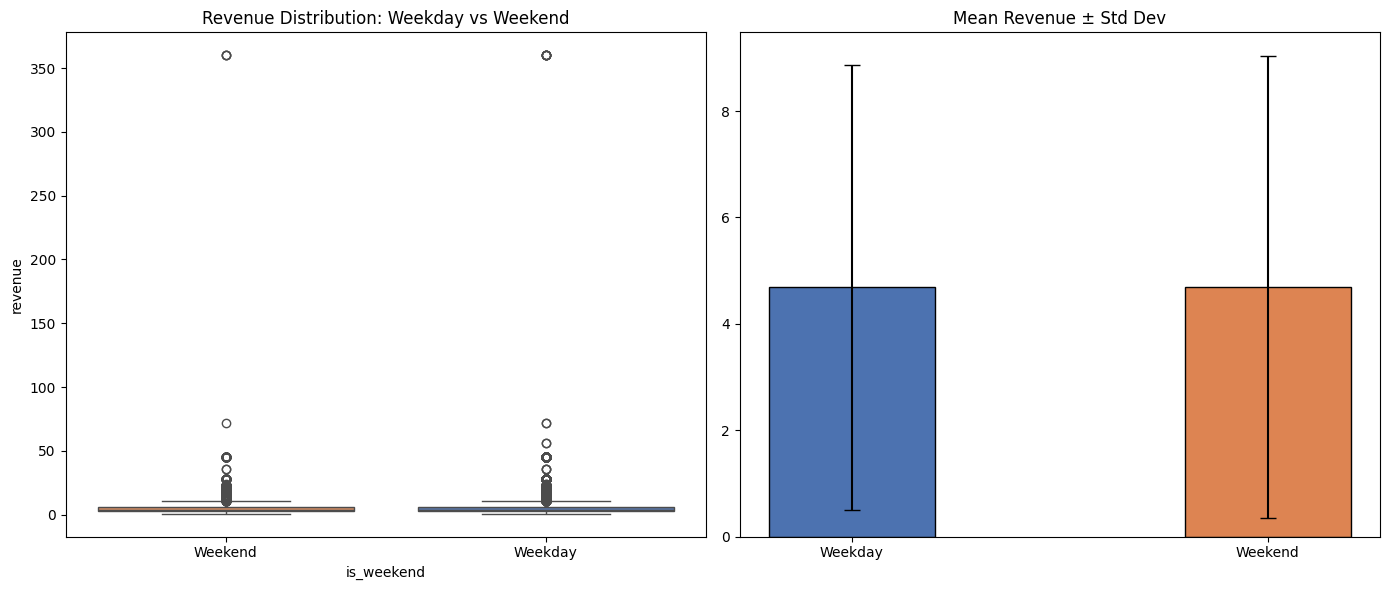

In [149]:
# Cell 4 — Boxplot + Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
day_labels = df['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

# Left: Distribution
sns.boxplot(x=day_labels, y=df['revenue'], 
            palette={'Weekday': '#4C72B0', 'Weekend': '#DD8452'}, ax=axes[0])
axes[0].set_title('Revenue Distribution: Weekday vs Weekend')

# Right: Comparison of Means
means = df.groupby(day_labels)['revenue'].mean()
stds  = df.groupby(day_labels)['revenue'].std()
axes[1].bar(means.index, means.values, yerr=stds.values, capsize=6, 
            color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.4)
axes[1].set_title('Mean Revenue ± Std Dev')

plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

In [150]:
from scipy.stats import mannwhitneyu

In [151]:
weekday_rev = df[df['is_weekend'] == False]['revenue']
weekend_rev = df[df['is_weekend'] == True]['revenue']

In [152]:
stat, p = mannwhitneyu(weekday_rev, weekend_rev, alternative='two-sided')
print(f"Mann-Whitney U: {stat:.2f}, p-value: {p:.4f}")

Mann-Whitney U: 2241181012.00, p-value: 0.5317


In [153]:
total_sales = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
print("Total Revenue by Store:")
print(total_sales.round(2))

Total Revenue by Store:
store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64


In [154]:
per_visit = df.groupby('store_location')['revenue'].mean().sort_values(ascending=False)
print("Average Spend Per Customer Visit:")
print(per_visit.round(4))

Average Spend Per Customer Visit:
store_location
Lower Manhattan    4.8147
Hell's Kitchen     4.6617
Astoria            4.5899
Name: revenue, dtype: float64


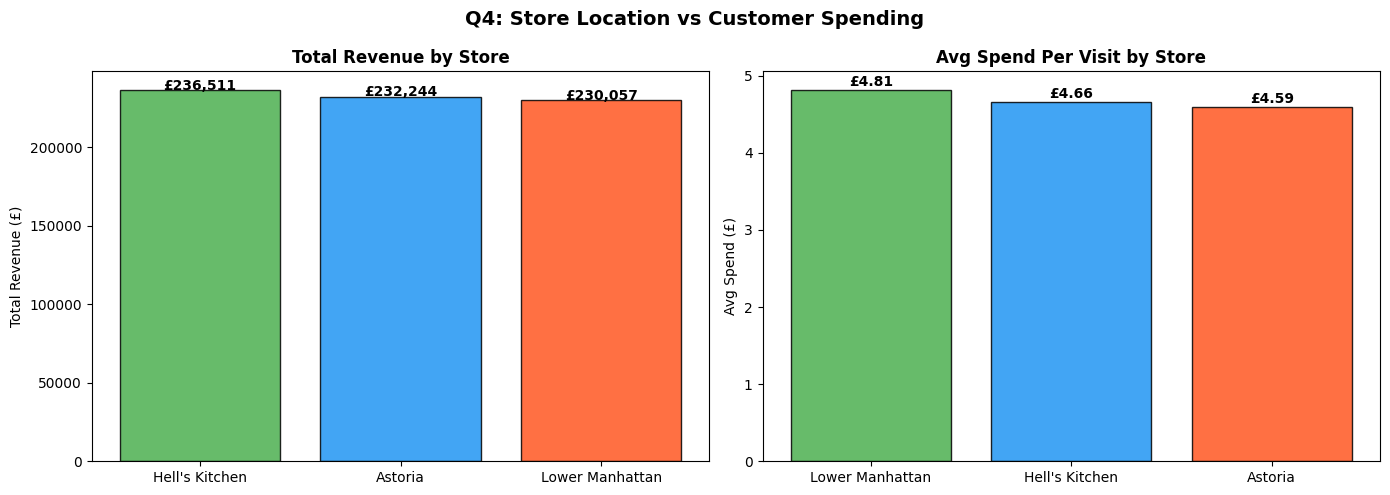

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Revenue
total_sales = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
axes[0].bar(total_sales.index, total_sales.values,
            color=['#4CAF50','#2196F3','#FF5722'], edgecolor='black', alpha=0.85)
axes[0].set_title('Total Revenue by Store', fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')
for i, v in enumerate(total_sales.values):
    axes[0].text(i, v + 100, f'£{v:,.0f}', ha='center', fontweight='bold')

# Avg Per Visit
per_visit = df.groupby('store_location')['revenue'].mean().sort_values(ascending=False)
axes[1].bar(per_visit.index, per_visit.values,
            color=['#4CAF50','#2196F3','#FF5722'], edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Spend Per Visit by Store', fontweight='bold')
axes[1].set_ylabel('Avg Spend (£)')
for i, v in enumerate(per_visit.values):
    axes[1].text(i, v + 0.05, f'£{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Q4: Store Location vs Customer Spending', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/revenue_vs_spend', dpi=150, bbox_inches='tight')
plt.show()

In [156]:
#ANOVA TEST
groups = [group['revenue'].values for _, group in df.groupby('store_location')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Location DOES influence spending!")
else:
    print("Fail to Reject H₀ — No significant difference.")

F-Statistic : 36.0889
P-Value     : 0.0000
Reject H₀ — Location DOES influence spending!


In [157]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats

tukey = pairwise_tukeyhsd(endog=df['revenue'],
                          groups=df['store_location'], alpha=0.05)
print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
       Astoria  Hell's Kitchen   0.0718 0.0188 0.0096  0.134   True
       Astoria Lower Manhattan   0.2248    0.0 0.1617  0.288   True
Hell's Kitchen Lower Manhattan    0.153    0.0 0.0899 0.2162   True
-------------------------------------------------------------------


In [158]:
#Question: Do weak categories perform equally poorly across all stores — or does any store show a hidden strength?
#Underperforming Products across stores

#Contigency table

weak_cats = ['Branded', 'Packaged Chocolate', 'Loose Tea']
df_weak = df[df['product_category'].isin(weak_cats)]

contingency = pd.crosstab(df_weak['product_category'], df_weak['store_location'])
print(contingency)

store_location      Astoria  Hell's Kitchen  Lower Manhattan
product_category                                            
Branded                 279             119              349
Loose Tea               344             485              381
Packaged Chocolate      110             197              180


In [159]:
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square : {chi2:.4f}")
print(f"P-Value    : {p:.4f}")
print(f"Degrees of Freedom: {dof}")

if p < 0.05:
    print("Reject H₀ — At least one store shows different sales for weak categories!")
else:
    print("Fail to Reject H₀ — Weak categories perform equally poorly everywhere.")

Chi-Square : 145.3083
P-Value    : 0.0000
Degrees of Freedom: 4
Reject H₀ — At least one store shows different sales for weak categories!


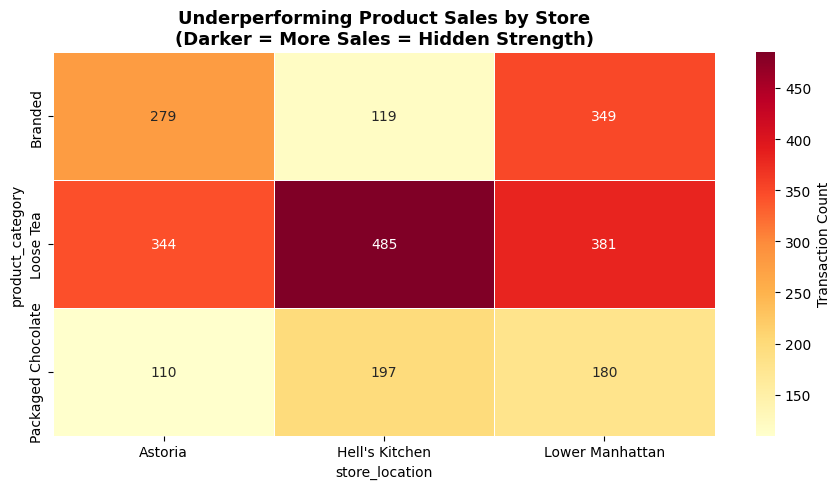

In [160]:
plt.figure(figsize=(9, 5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Transaction Count'})
plt.title('Underperforming Product Sales by Store\n(Darker = More Sales = Hidden Strength)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/underperforming_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

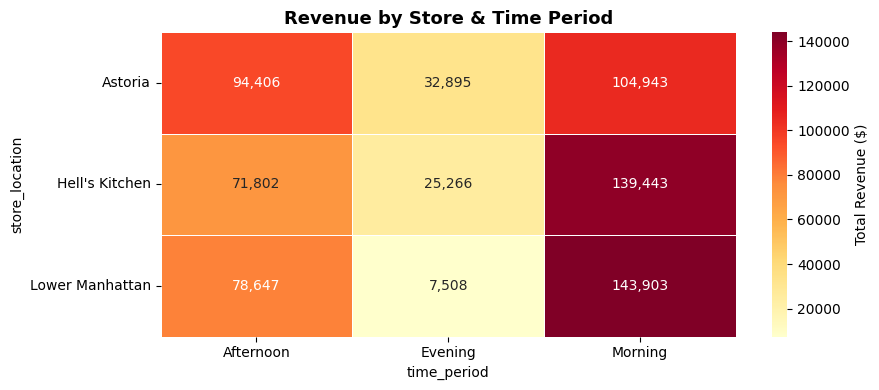

In [327]:
import seaborn as sns

revenue_time = df.groupby(['store_location', 'time_period'])['revenue'].sum().unstack()

plt.figure(figsize=(9, 4))
sns.heatmap(revenue_time, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Total Revenue ($)'})
plt.title('Revenue by Store & Time Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/revenue_heatmap_store_time.png', dpi=150, bbox_inches='tight')
plt.show()

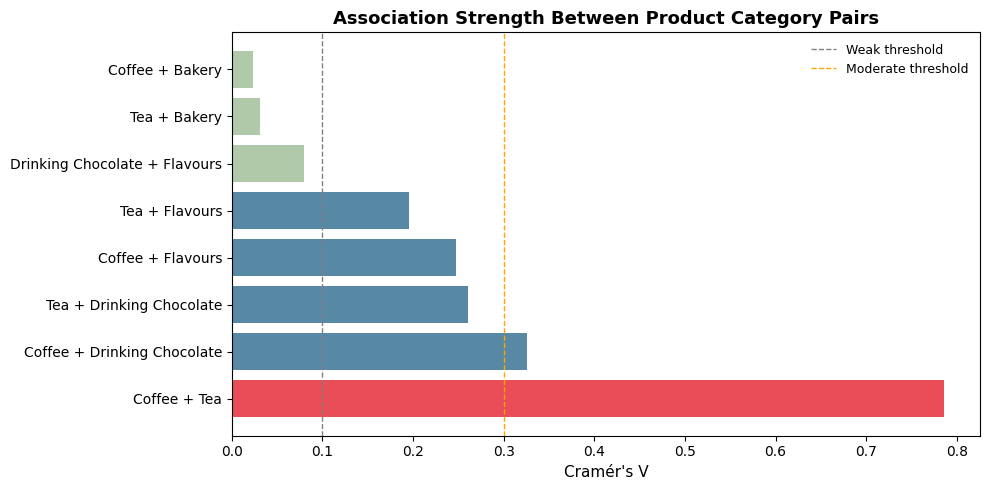

In [329]:
top_pairs = results_df.head(8)

plt.figure(figsize=(10, 5))
colors_v = ['#E63946' if v >= 0.5 else '#457B9D' if v >= 0.1 else '#A8C5A0' 
            for v in top_pairs['cramers_v']]
bars = plt.barh(top_pairs['pair'], top_pairs['cramers_v'], 
                color=colors_v, edgecolor='none', alpha=0.9)
plt.axvline(x=0.1, color='gray', linestyle='--', linewidth=1, label='Weak threshold')
plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=1, label='Moderate threshold')
plt.xlabel("Cramér's V", fontsize=11)
plt.title("Association Strength Between Product Category Pairs", 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('D:/Data_analysis/coffee_shop_analysis/cramers_v_pairs.png', dpi=150, bbox_inches='tight')
plt.show()